In [1]:
import pickle
import torch
import pandas as pd
import numpy as np
import time
import os
import sys
sys.path.append('src/')
%load_ext autoreload
%autoreload 2

In [ ]:
import pickle
import numpy as np

from tqdm import tqdm
from pathlib import Path

from src.utils import calc_capacity, calc_V_of_Q, calc_dV_over_dQ, interpolate_element

def compute_power_and_energy_time(
        t, V, I
    ):
    # Instantaneous power
    P = V * I   # in Watts (V × A)

    # Compute cumulative energy by trapezoidal integration of P(t) over time
    # If time in seconds → E in Joules; we'll convert to Wh if desired.
    E_J = np.zeros_like(P)
    # We'll compute incremental energy between samples, then cumulative sum
    E_cum_J = np.zeros_like(P)
    for k in range(1, len(t)):
      dt = t[k] - t[k-1]      # time difference
      # average power over interval
      P_avg = 0.5 * (P[k] + P[k-1])
      E_interval = P_avg * dt
      E_cum_J[k] = E_cum_J[k-1] + E_interval
    # Convert to Wh if time was in seconds
    
    E_cum_Wh = E_cum_J / 3600.0
  
    return P, E_cum_Wh

def load_data_from_file(file_path, is_matr=False):
    data = {}
    labels = {}
    with open(file_path, 'rb') as f:
        cell_data = pickle.load(f)
    
    Q_min, Q_max = 0, 0.02
    V_min, V_max = 2, 3.6
    for cell_name, cell_info in cell_data['cycle_infos'].items():
        new_cell_data = []
        data[cell_name] = new_cell_data
        labels[cell_name] = float(cell_data['ruls'][cell_name][0][0])
    return data, labels

def load_data(root_dir, is_matr=False):
    def calc_delta(x):
        x = x - np.roll(x, 1)
        x[0] = 0.
        return x
    data = {}

    for cell_file in tqdm(list(Path(root_dir).glob('*.pkl')), desc='Loading cells'):
        # cell_name = cell_file.stem
        res = load_data_from_file(cell_file, is_matr=is_matr)

        data.update(res)

    return data

In [3]:
import pickle
import numpy as np

from tqdm import tqdm
from pathlib import Path

from src.utils import calc_capacity, calc_V_of_Q, calc_dV_over_dQ, interpolate_element

def load_data(root_dir, is_ours=True, interp_dims=1000, Q_min=0, Q_max=2.2, V_min=2.5, V_max=4.2, all_label=None):
    def calc_delta(x):
        x = x - np.roll(x, 1)
        x[0] = 0.
        return x
    data = {}
    labels = {}
    # max_V, min_V = 0, 10
    
    for cell_file in tqdm(list(Path(root_dir).glob('*.pkl')), desc='Loading cells'):
        # print(cell_file)
        cell_name = cell_file.stem.split('_')[1]
        if all_label is not None and cell_name not in all_label.keys():
            # print(f"Skipping {cell_name} as it's not in all_label")
            continue
        with open(cell_file, 'rb') as f:
            cell_data = pickle.load(f)
        new_cell_data = []
        for cycle, cycle_data in enumerate(cell_data['cycle_data']):
            if is_ours:
                cycle_data['QV_d'] = interpolate_element(cycle_data['Q_d(V_d)'][0], cycle_data['Q_d(V_d)'][1], device='cpu', inter_num=interp_dims)
                cycle_data['QV_c'] = interpolate_element(cycle_data['Q_c(V_c)'][0], cycle_data['Q_c(V_c)'][1], device='cpu', inter_num=interp_dims)

                cycle_data['interp_E_c'] = interpolate_element(cycle_data['t_c'], cycle_data['E_c'], device='cpu', inter_num=interp_dims)
                cycle_data['interp_W_c'] = interpolate_element(cycle_data['t_c'], cycle_data['W_c'], device='cpu', inter_num=interp_dims)
                cycle_data['interp_E_d'] = interpolate_element(cycle_data['t_d'], cycle_data['E_d'], device='cpu', inter_num=interp_dims)
                cycle_data['interp_W_d'] = interpolate_element(cycle_data['t_d'], cycle_data['W_d'], device='cpu', inter_num=interp_dims)

            else:
                cycle_data['QV_d'] = torch.tensor(cycle_data['Qdlin'])

            new_cell_data.append(cycle_data)
        data[cell_name] = new_cell_data

        if all_label is not None:
            labels[cell_name] = all_label[cell_name]
        else:
            labels[cell_name] = float(cell_data['ruls'][cell_name][0][0])

        # break
    return data, labels

In [4]:
root_dir = './data/MATR'

train_data, train_labels = load_data_from_file(os.path.join(root_dir, 'train_1000.pkl'), is_matr=True)
test1_data, test1_labels = load_data_from_file(os.path.join(root_dir, 'test1_1000.pkl'), is_matr=True)
test2_data, test2_labels = load_data_from_file(os.path.join(root_dir, 'test2_1000.pkl'), is_matr=True)


# all_data = {**train_data, **test1_data, **test2_data}
all_label = {**train_labels, **test1_labels, **test2_labels}


/tmp/ipykernel_4162975/3744631580.py:36: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  cell_data = pickle.load(f)


In [5]:
root_dir = '/data/Blob_EastUS/xiaofan/battery/BatteryML/data/processed/MATR'
data, labels = load_data(root_dir, is_ours=False, interp_dims=1000, Q_min=0, Q_max=2.2, V_min=2.5, V_max=4.2, all_label=all_label)

Loading cells: 100%|██████████| 180/180 [02:04<00:00,  1.45it/s]


In [6]:
all_data = data.copy()

In [7]:
from src.learning import random_fit_and_eval, RMSE, MAPE
from functools import partial
from src.utils import (
    diff_cycles,
    savgol_smooth,
    nankurtosis,
    nanmax,
    nanmin,
    nanmean,
    nanskew,
    nanvar
)
import torch
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

In [8]:

scores = {}
seeds = list(range(16))  # Randomness for dataset split and model initialization
evaluators = [RMSE(log_scale=True), MAPE(log_scale=True)]
num_early_cycles = 50

smoother = partial(savgol_smooth, window=51, order=3)


In [9]:
# concat data together
y_relative = np.array([
    label for _, label in all_label.items() if label > num_early_cycles
])

X_relative = torch.stack([
    torch.stack([
        torch.stack([
             torch.as_tensor(cycle_data['QV_d'])
            # cycle_data['VQ_c'], cycle_data['VQ_d'],
            # cycle_data['dVdQ_c'], cycle_data['dVdQ_d'], 
            # cycle_data['interp_I_c'], cycle_data['interp_I_d'],
            # cycle_data['interp_V_c'], cycle_data['interp_V_d'],
            # cycle_data['QV_c'], cycle_data['QV_d'],
            # cycle_data['interp_E_c'], cycle_data['interp_E_d'],
            # cycle_data['interp_W_c'], cycle_data['interp_W_d']
        ]) for cycle_data in all_data[cell][:num_early_cycles]
    ]) for cell, label in all_label.items() if label > num_early_cycles
]).permute(0, 2, 1, 3).contiguous()


In [10]:
import matplotlib.pyplot as plt
def plot_curves(cycle_data, x_col, y_col, interpolate_col):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

    ax1.plot(cycle_data[x_col], cycle_data[y_col])
    ax1.set_xlabel(x_col)
    ax1.set_ylabel(y_col)
    ax2.plot(cycle_data[interpolate_col])
    ax2.set_ylabel(interpolate_col)


In [11]:
X_qdlinear = np.stack([
    np.stack([
        cycle_data['QV_d']
        for cycle_data in all_data[cell][:num_early_cycles]
    ]) 
    for cell, label in all_label.items() if label > num_early_cycles
])
X_qdlinear.shape

(124, 50, 1000)

In [12]:
def print_score(model_score):
    mean_score = np.mean(model_score, axis=0).squeeze(), np.std(model_score, axis=0).squeeze()
    train_RMSE, test_RMSE, train_RMSE_variance, test_RMSE_variance =  mean_score[0][0][0], mean_score[0][0][1], mean_score[1][0][0], mean_score[1][0][1]
    train_MAPE, test_MAPE, train_MAPE_variance, test_MAPE_variance  =  mean_score[0][1][0], mean_score[0][1][1], mean_score[1][1][0], mean_score[1][1][1]
    print(f'train_RMSE:{train_RMSE:.2f} ± {train_RMSE_variance:.0f}, test_RMSE:{test_RMSE:.2f} ± {test_RMSE_variance:.0f}' )
    print(f'train_MAPE:{train_MAPE:.2f} ± {train_MAPE_variance:.0f}, test_MAPE:{test_MAPE:.2f} ± {test_MAPE_variance:.0f}' )

In [13]:
evaluators = [RMSE(log_scale=True), MAPE(log_scale=True)]
predictions = {}
scores = {}
key = 'dummy'
scores[key] = []
predictions[key] = []

train_idxs = [i for i in range(0,41)]
test1_idxs =[i for i in range(41,84)]
# test2_idxs =[i for i in range(84,124)]
test2_idxs =[i for i in range(84,len(y_relative))]
X, y = X_qdlinear, y_relative
for seed in seeds:
    score, y_test, y_pred = random_fit_and_eval(
            X.reshape(len(X), -1),
            np.log(y_relative),
            models=[DummyRegressor()],
            evaluators=evaluators,
            seed=seed,
            return_prediction=True,
            return_train_loss=True,
            train_idx=train_idxs, 
            test_idx=test1_idxs
        )
    scores[key].append(score)
    predictions[key].append([y_test, y_pred])

print('Test1 results:')
print(f'model: {key}')
print_score(scores[key])


for seed in seeds:
    score, y_test, y_pred = random_fit_and_eval(
            X.reshape(len(X), -1),
            np.log(y_relative),
            models=[DummyRegressor()],
            evaluators=evaluators,
            seed=seed,
            return_prediction=True,
            return_train_loss=True,
            train_idx=train_idxs, 
            test_idx=test2_idxs
        )
    scores[key].append(score)
    predictions[key].append([y_test, y_pred])
print('Test2 results:')
print(f'model: {key}')
print_score(scores[key])

Test1 results:
model: dummy
train_RMSE:327.21 ± 0, test_RMSE:400.74 ± 0
train_MAPE:29.63 ± 0, test_MAPE:35.00 ± 0
Test2 results:
model: dummy
train_RMSE:327.21 ± 0, test_RMSE:455.68 ± 55
train_MAPE:29.63 ± 0, test_MAPE:35.53 ± 1


# Variance model

In [24]:

X_diff = X_qdlinear[:, num_early_cycles-2] - X_qdlinear[:, 8]
# X_diff = X_qdlinear[:, num_early_cycles-2, :] - X_qdlinear[:, 8, :]

y = y_relative
Vdlin = np.linspace(3.6, 2, 100)
axis = 1
functions = {
    'variance model':   lambda x:np.var(x,axis=axis),
}
var_pred = []
for k, func in enumerate(functions):
    # print(k, func)
    key = func
    scores[key] = []
    predictions[key] = []
    X = np.log10(np.abs(functions[func](X_diff))).reshape(-1, 1)
    # X = np.log10(np.abs(functions[func](X_diff)))

    X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)
    
    for seed in seeds:
        score, y_test, y_pred = random_fit_and_eval(X, np.log(y), [LinearRegression()], evaluators, seed=seed, need_normalize=False, return_prediction=True, return_train_loss=True, 
                                                    train_idx=train_idxs,  test_idx=test1_idxs)
        scores[key].append(score)
        predictions[key].append([y_test, y_pred])
        var_pred = y_pred
        
        break
    print(f'test1 result model: {key}')
    print_score(score)
    print('\n')

    for seed in seeds:
        score, y_test, y_pred = random_fit_and_eval(X, np.log(y), [LinearRegression()], evaluators, seed=seed, need_normalize=False, return_prediction=True, return_train_loss=True, 
                                                    train_idx=train_idxs,  test_idx=test2_idxs)
        scores[key].append(score)
        predictions[key].append([y_test, y_pred])
        break

    print(f'test2 result model: {key}')
    print_score(score)
    print('\n')


test1 result model: variance model
train_RMSE:155.80 ± 0, test_RMSE:197.79 ± 0
train_MAPE:18.06 ± 0, test_MAPE:20.40 ± 0


test2 result model: variance model
train_RMSE:155.80 ± 0, test_RMSE:258.40 ± 0
train_MAPE:18.06 ± 0, test_MAPE:15.80 ± 0




In [145]:
# #100cycle
# model: variance model
# train_RMSE:110.88 ± 0, test_RMSE:145.40 ± 0
# train_MAPE:14.71 ± 0, test_MAPE:15.50 ± 0

# # 50cycle
# model: variance model
# train_RMSE:164.29 ± 0, test_RMSE:144.09 ± 0
# train_MAPE:18.93 ± 0, test_MAPE:18.01 ± 0


# Discharge model

In [147]:
# from scipy.stats import skew, kurtosis
# def normalize_discharge_features(data):
#     functions = {
#         'min' :    lambda x: np.min(x, axis=1),
#         'var':     lambda x: np.var(x, axis=1),
#         'skew':    lambda x: skew(x, axis=1),
#         'kurt':    lambda x: kurtosis(x, axis=1),
#     }
    
#     DeltaQ_50_minus_10 = X_qdlinear[:, num_early_cycles-2, :] - X_qdlinear[:, 8, :]
#     X = np.ones((DeltaQ_50_minus_10.shape[0],len(functions)+2))
#     for k, func in enumerate(functions):
#         feat = functions[func](DeltaQ_50_minus_10)
#         X[:,k] = feat
#     X[:,-2] = data[:,0,1]
#     X[:,-1] = np.amax(data[:,0,:],axis=1)- data[:,0,1]
#     X[np.isinf(X)] = 0.0
#     return X

# key = 'discharge'
# scores[key] = []
# predictions[key] = []
# X = normalize_discharge_features(X_qdlinear)

# X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

# for seed in seeds:
#     score, y_test, y_pred = random_fit_and_eval(X, np.log(y), [LinearRegression()], evaluators, seed=seed, need_normalize=True, return_prediction=True, return_train_loss=True, train_idx=train_idxs, 
#             test_idx=test1_idxs)
#     # score, y_test, y_pred = random_fit_and_eval(X, np.log(y), [LinearRegression()], evaluators, seed=seed, need_normalize=True, return_prediction=True, return_train_loss=True, train_idx=train_idxs, 
#     #         test_idx=test2_idxs)
#     scores[key].append(score)
#     predictions[key].append([y_test, y_pred])

# print(f'model: {key}')
# print_score(scores[key])


model: discharge
train_RMSE:92.16 ± 0, test_RMSE:541.93 ± 0
train_MAPE:9.39 ± 0, test_MAPE:20.61 ± 0


In [15]:
# # test1
# model: discharge
# train_RMSE:107.57 ± 0, test_RMSE:240.70 ± 0
# train_MAPE:9.26 ± 0, test_MAPE:13.96 ± 0

# # test2
# model: discharge
# train_RMSE:83.83 ± 0, test_RMSE:435.88 ± 0
# train_MAPE:8.38 ± 0, test_MAPE:30.01 ± 0

In [16]:
from src.learning import tree_models_fit_and_eval
X = X_qdlinear[:, num_early_cycles-2, :] - X_qdlinear[:, 8, :]
X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

res_score, res_pred = tree_models_fit_and_eval(X, np.log(y), evaluators, [0], need_normalize=True, return_prediction=True, return_train_loss=True,
                                                 train_idx=train_idxs, test_idx=test1_idxs )

for key in res_score.keys():
    scores[key] = res_score[key]
    predictions[key] = res_pred[key]

    print(f'model: {key}')
    print_score(scores[key])


/home/xiaofangui/miniconda3/lib/python3.13/site-packages/sklearn/model_selection/_validation.py:516: FitFailedWarning: 
260 fits failed out of a total of 500.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
147 fits failed with the following error:
Traceback (most recent call last):
  File "/home/xiaofangui/miniconda3/lib/python3.13/site-packages/sklearn/model_selection/_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/xiaofangui/miniconda3/lib/python3.13/site-packages/sklearn/base.py", line 1356, in wrapper
    estimator._validate_params()
    ~~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "/home/xiaofangui/miniconda3/lib/python3.13/site-pa

{'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 80, 'bootstrap': True}
RF
model: RF
train_RMSE:160.33 ± 0, test_RMSE:237.32 ± 0
train_MAPE:9.03 ± 0, test_MAPE:20.47 ± 0


In [149]:
res_score, res_pred = tree_models_fit_and_eval(X, np.log(y), evaluators, [0], need_normalize=True, return_prediction=True, return_train_loss=True,
                                                 train_idx=train_idxs, test_idx=test2_idxs )

for key in res_score.keys():
    scores[key] = res_score[key]
    predictions[key] = res_pred[key]

    print(f'model: {key}')
    print_score(scores[key])


/home/xiaofangui/miniconda3/lib/python3.13/site-packages/sklearn/model_selection/_validation.py:516: FitFailedWarning: 
260 fits failed out of a total of 500.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
140 fits failed with the following error:
Traceback (most recent call last):
  File "/home/xiaofangui/miniconda3/lib/python3.13/site-packages/sklearn/model_selection/_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/xiaofangui/miniconda3/lib/python3.13/site-packages/sklearn/base.py", line 1356, in wrapper
    estimator._validate_params()
    ~~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "/home/xiaofangui/miniconda3/lib/python3.13/site-pa

{'n_estimators': 2000, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 30, 'bootstrap': False}
RF
model: RF
train_RMSE:82.50 ± 0, test_RMSE:214.25 ± 0
train_MAPE:2.71 ± 0, test_MAPE:17.83 ± 0


In [37]:
# from src.learning import MLP_rul_estimator, random_fit_and_eval_nn
# key = 'MLP'
# scores[key] = []
# predictions[key] = []
# X = X_qdlinear[:, num_early_cycles-2, :] - X_qdlinear[:, 8, :]
# X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)


# for seed in seeds:
#     score, pred = random_fit_and_eval_nn(X, np.log(y), [MLP_rul_estimator], evaluators, seed=seed,need_zscore=True, return_prediction=True , return_train_loss=True, train_idx=train_idxs, test_idx=test1_idxs )
#     scores[key].append(score)
#     predictions[key].append(pred[0])

# print(f'model: {key}')
# print_score(scores[key])

Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x7c3d88cde510>>
Traceback (most recent call last):
  File "/home/xiaofangui/miniconda3/lib/python3.13/site-packages/ipykernel/ipkernel.py", line 775, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(
KeyboardInterrupt: 


model: MLP
train_RMSE:161.31 ± 0, test_RMSE:268.77 ± 0
train_MAPE:15.30 ± 0, test_MAPE:18.01 ± 0


# Our model

In [17]:
from src.feature import our_feature
def get_slope_intercept(y):
    x = np.linspace(1, len(y), len(y))
    z = np.polyfit(x, y, 1)
    return z


task_type = 'relative'

X, y = eval(f'X_{task_type}'), eval(f'y_{task_type}')
key = 'Ours'
X_ours, fea_names = our_feature(
    X,
    num_cycle_groups=5,
    num_signal_segments=4,
    aggregators=[
        nankurtosis, nanmax, nanmin, nanmean, nanvar, nanskew
    ],
    activators=[
        lambda x: x,  # identity
        torch.abs
    ],
    build_feature_name= True,
    device='cuda:0'
)
print(X_ours.shape, len(fea_names))
X_ours = np.nan_to_num(X_ours, nan=0.0, posinf=0.0, neginf=0.0)


scores[key] = []
predictions[key] = []
feature_importances = []
for seed in tqdm(seeds, desc=f'Processing {key}'):
    score, test_y, test_pred = random_fit_and_eval(
        X_ours, np.log(y), [RandomForestRegressor()], evaluators, seed=seed, return_prediction= True, return_train_loss=True, 
        train_idx=train_idxs, test_idx=test1_idxs 
    )

    scores[key].append(score)
    predictions[key].append(test_pred)

print(f'model: {key}')
print_score(scores[key])

for seed in tqdm(seeds, desc=f'Processing {key}'):
    score, test_y, test_pred = random_fit_and_eval(
        X_ours, np.log(y), [RandomForestRegressor()], evaluators, seed=seed, return_prediction= True, return_train_loss=True, 
        train_idx=train_idxs, test_idx=test2_idxs 
    )

    scores[key].append(score)
    predictions[key].append(test_pred)

print(f'model: {key} test2')
print_score(scores[key])

(124, 4320) 4320


Processing Ours: 100%|██████████| 16/16 [01:24<00:00,  5.26s/it]


model: Ours
train_RMSE:111.15 ± 10, test_RMSE:230.88 ± 9
train_MAPE:4.69 ± 0, test_MAPE:16.90 ± 0


Processing Ours: 100%|██████████| 16/16 [01:24<00:00,  5.27s/it]

model: Ours test2
train_RMSE:111.15 ± 10, test_RMSE:273.03 ± 44
train_MAPE:4.69 ± 0, test_MAPE:16.43 ± 1


In [36]:
score, feature_importances_top20, top_idxs = random_fit_and_eval(
    X_ours, np.log(y), [RandomForestRegressor()], evaluators, feature_name=fea_names, need_normalize=False, seed=0, return_prediction= True, return_train_loss=True, 
    train_idx=train_idxs, test_idx=test1_idxs , top_k=20
)
scores = {}
key ='our_normalized_top20'
scores[key] = []
predictions[key] = []
seeds = list(range(16))
for seed in tqdm(seeds, desc=f'Processing {key}'):
    score, y_test, y_pred = random_fit_and_eval(
        X_ours[:,top_idxs], np.log(y), [RandomForestRegressor()], evaluators, feature_name=None, need_normalize=False, seed=seed, return_prediction= True, return_train_loss=True, 
        train_idx=train_idxs, test_idx=test1_idxs 
    )
    scores[key].append(score)
    break
    # predictions[key].append(test_pred)

print(f'model: {key}')
print_score(scores[key])

for seed in tqdm(seeds, desc=f'Processing {key}'):
    score, _, _ = random_fit_and_eval(
        X_ours[:,top_idxs], np.log(y), [RandomForestRegressor()], evaluators, feature_name=fea_names, need_normalize=False, seed=seed, return_prediction= True, return_train_loss=True, 
        train_idx=train_idxs, test_idx=test2_idxs 
    )
    scores[key].append(score)
    # predictions[key].append(test_pred)
    break

print(f'model: {key}')
print_score(scores[key])

Processing our_normalized_top20:   0%|          | 0/16 [00:00<?, ?it/s]


model: our_normalized_top20
train_RMSE:90.00 ± 0, test_RMSE:192.90 ± 0
train_MAPE:4.17 ± 0, test_MAPE:16.77 ± 0


Processing our_normalized_top20:   0%|          | 0/16 [00:00<?, ?it/s]

model: our_normalized_top20
train_RMSE:90.00 ± 0, test_RMSE:221.34 ± 28
train_MAPE:4.17 ± 0, test_MAPE:15.98 ± 1


In [136]:
pd.DataFrame(data=feature_importances_top20, columns=['feature_name', 'importance']).to_csv('./output/feature_importance_matr_top20.csv', index=False)

In [37]:
score, feature_importances_top10, top_idxs = random_fit_and_eval(
    X_ours, np.log(y), [RandomForestRegressor()], evaluators, feature_name=fea_names, need_normalize=False, seed=0, return_prediction= True, return_train_loss=True, 
    train_idx=train_idxs, test_idx=test1_idxs , top_k=10
)
scores = {}
key ='our_normalized_top10'
scores[key] = []
predictions[key] = []
seeds = list(range(16))
for seed in tqdm(seeds, desc=f'Processing {key}'):
    score, y_test, y_pred = random_fit_and_eval(
        X_ours[:,top_idxs], np.log(y), [RandomForestRegressor()], evaluators, feature_name=None, need_normalize=True, seed=seed, return_prediction= True, return_train_loss=True, 
        train_idx=train_idxs, test_idx=test1_idxs 
    )
    scores[key].append(score)
    break
    # predictions[key].append(test_pred)

print(f'model: {key}')
print_score(scores[key])

for seed in tqdm(seeds, desc=f'Processing {key}'):
    score, _, _ = random_fit_and_eval(
        X_ours[:,top_idxs], np.log(y), [RandomForestRegressor()], evaluators, feature_name=fea_names, need_normalize=True, seed=seed, return_prediction= True, return_train_loss=True, 
        train_idx=train_idxs, test_idx=test2_idxs 
    )
    scores[key].append(score)
    # predictions[key].append(test_pred)
    break

print(f'model: {key}')
print_score(scores[key])

Processing our_normalized_top10:   0%|          | 0/16 [00:00<?, ?it/s]


model: our_normalized_top10
train_RMSE:89.69 ± 0, test_RMSE:187.96 ± 0
train_MAPE:4.53 ± 0, test_MAPE:16.68 ± 0


Processing our_normalized_top10:   0%|          | 0/16 [00:00<?, ?it/s]

model: our_normalized_top10
train_RMSE:89.69 ± 0, test_RMSE:214.62 ± 27
train_MAPE:4.53 ± 0, test_MAPE:17.21 ± 1


In [137]:
pd.DataFrame(data=feature_importances_top10, columns=['feature_name', 'importance']).to_csv('./output/feature_importance_matr_top10.csv', index=False)

In [ ]:
# # 用前50圈数据作为early cycle
# dummy:
# test1:400
# test2:455
# variance_model(1 feature + lr):
# test1:197.79
# test2:258
# variance feature 99-9(1000 point) + rf model:
# test1: 237.32 ± 0 
# test2: 268.77 ± 0 
# our model(cycle group:5, segment:4):
# test1:230
# test2:315.18
# our model(cycle group:5, segment:4, top 10 features):
# test1:192.23
# test2:218
# our model(cycle group:5, segment:4, top 20 features):
# test1:191.07
# test2:220.83

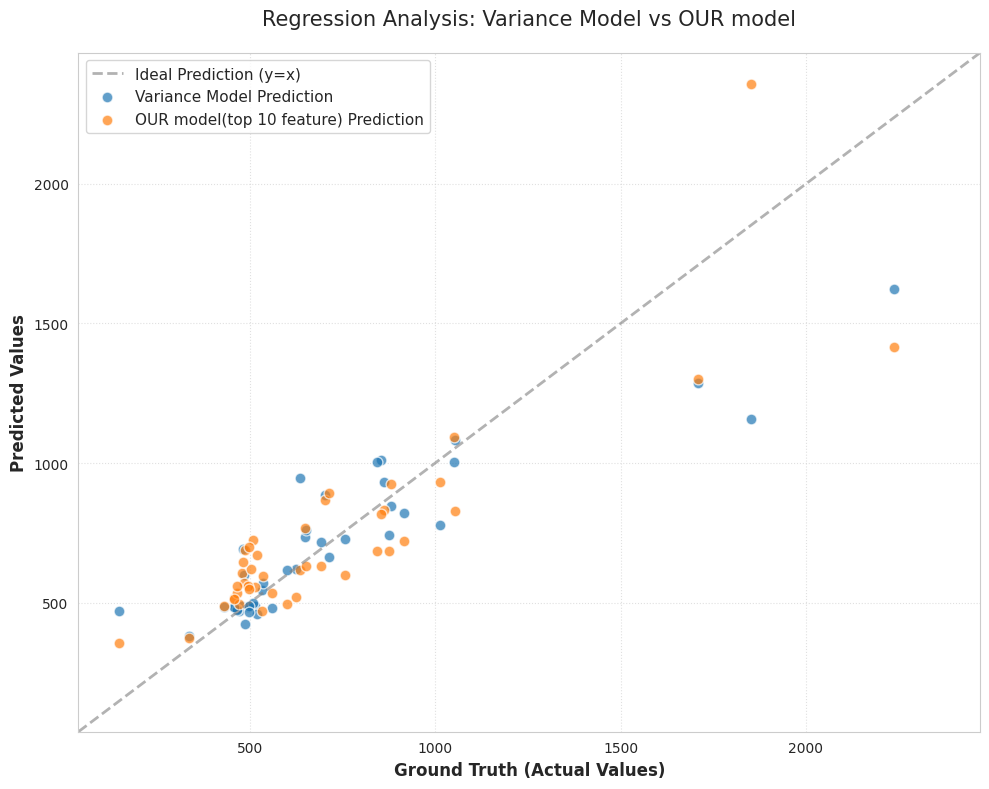

In [39]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# 设置绘图风格，更美观
sns.set_style("whitegrid")

# 假设你的数据变量名如下 (你需要确保你的环境中已经有这些变量)
# y_test = ...
# y_pred = ... (模型A)
# var_pred = ... (模型B，对应你图中的橙色)

plt.figure(figsize=(10, 8), dpi=100) # 增加分辨率和尺寸

# 1. 绘制对角线 (参考线)
# 获取坐标轴范围，确保对角线贯穿整个图
all_values = np.concatenate([y_test, y_pred, var_pred])
min_val = np.min(all_values)
max_val = np.max(all_values)
# 留一点边距
padding = (max_val - min_val) * 0.05
limit_min = min_val - padding
limit_max = max_val + padding

plt.plot([limit_min, limit_max], [limit_min, limit_max], 
         color='gray', linestyle='--', linewidth=2, alpha=0.6, label='Ideal Prediction (y=x)')

# 2. 绘制散点图
# 使用 alpha 设置透明度，防止点重叠看不清
# s 设置点的大小
# edgecolors 给点加个边框，更清晰
plt.scatter(y_test, y_pred, c='#1f77b4', alpha=0.7, s=60, edgecolors='w', label='Variance Model Prediction')
plt.scatter(y_test, var_pred, c='#ff7f0e', alpha=0.7, s=60, edgecolors='w', label='OUR model(top 10 feature) Prediction')

# 3. 添加标签和标题
plt.xlabel('Ground Truth (Actual Values)', fontsize=12, fontweight='bold')
plt.ylabel('Predicted Values', fontsize=12, fontweight='bold')
plt.title('Regression Analysis: Variance Model vs OUR model', fontsize=15, pad=20)

# 4. 设置轴的范围一致，这样对角线才是 45 度
plt.xlim(limit_min, limit_max)
plt.ylim(limit_min, limit_max)

# 5. 添加图例
plt.legend(loc='upper left', frameon=True, fontsize=11)

# 6. (可选) 添加网格线，帮助读数 (seaborn style 默认会有，这里显式微调)
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.savefig('./output/matr_variance_vs_ourmodel.png', dpi=300)
# plt.show()